# Job Salary Prediction - End-to-End Machine Learning Project

---

## Problem Statement

**Objective:** Build a machine learning model to predict the annual salary (in USD) of tech professionals based on their job characteristics.

**Problem Type:** Regression (predicting a continuous numerical value)

**Business Context:** Understanding salary determinants helps:
- Job seekers negotiate fair compensation
- HR departments set competitive salary ranges
- Companies benchmark against industry standards

**Target Variable:** `salary` (annual salary in USD)

**Features:**
- `job_title`: Role/position (Data Scientist, Software Engineer, etc.)
- `experience_years`: Years of professional experience
- `education_level`: Highest education attained
- `skills_count`: Number of relevant technical skills
- `industry`: Sector of employment
- `company_size`: Size of the employer organization
- `location`: Geographic location
- `remote_work`: Remote work arrangement
- `certifications`: Number of professional certifications

---

## Project Workflow

| Module | Topics |
|--------|--------|
| **1. Data Preparation** | Loading, EDA, Cleaning, Encoding |
| **2. Baseline Model** | Linear Regression, Train/Test Split, Metrics |
| **3. Model Optimization** | Scaling, Regularization (Ridge/Lasso), K-Means, PCA |
| **4. Advanced Models** | Decision Tree, Random Forest, Hyperparameter Tuning, Comparison |

In [ ]:
plots/
├── 01_salary_distribution.png      ✓
├── 02_numerical_distributions.png  ✓
├── 03_salary_by_job_title.png      ✓
├── 04_salary_by_education.png      ✓
├── 05_salary_by_company_size.png   ✓
├── 06_salary_by_location.png       ✓
├── 07_correlation_heatmap.png      ✓
├── 08_experience_vs_salary.png     ✓
├── 09_outlier_treatment.png        ✓
├── 10_log_transformation.png       ✓
├── 11_lr_predictions.png           ✓
├── 12_regularization_comparison.png ✓
├── 13_kmeans_elbow.png             ✓
├── 14_kmeans_clusters.png          ✓
├── 15_pca_analysis.png             ✓
├── 16_pca_2d_visualization.png     ✓
├── 17_feature_importance.png       ✓
├── 18_model_comparison.png         ✓
└── 19_best_model_predictions.png   ✓

---

# Module 1: Data Understanding & Preprocessing

---

## 1.1 Import Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats.mstats import winsorize

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model persistence
import joblib

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Create plots directory
os.makedirs('plots', exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1.2 Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv('job_salary_prediction_dataset.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 250,000 rows × 10 columns


## 1.3 Dataset Overview

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
# Dataset information
print("Dataset Information:")
print("=" * 50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
# Statistical summary for numerical columns
print("Statistical Summary (Numerical Features):")
df.describe()

Statistical Summary (Numerical Features):


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [6]:
# Categorical columns summary
print("Categorical Features Summary:")
print("=" * 50)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())

Categorical Features Summary:

job_title: 12 unique values
job_title
Backend Developer        21125
Cybersecurity Analyst    20959
Product Manager          20950
AI Engineer              20945
Data Scientist           20890
Name: count, dtype: int64

education_level: 5 unique values
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

industry: 10 unique values
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Name: count, dtype: int64

company_size: 5 unique values
company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dtype: int64

location: 10 unique values
location
Australia    25258
Canada       25165
Sweden       25100
Remote       25065
Singapore    25035
Name: count, dtype: int64

remote_work: 3 unique values
remote_work
No        83621
Hybri

## 1.4 Check for Missing Values and Duplicates

In [7]:
# Missing values check
print("Missing Values per Column:")
print("=" * 50)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values per Column:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Total missing values: 0


In [8]:
# Duplicate records check
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows...")
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")

Number of duplicate rows: 0


## 1.5 Exploratory Data Analysis (EDA)

### 1.5.1 Target Variable Distribution

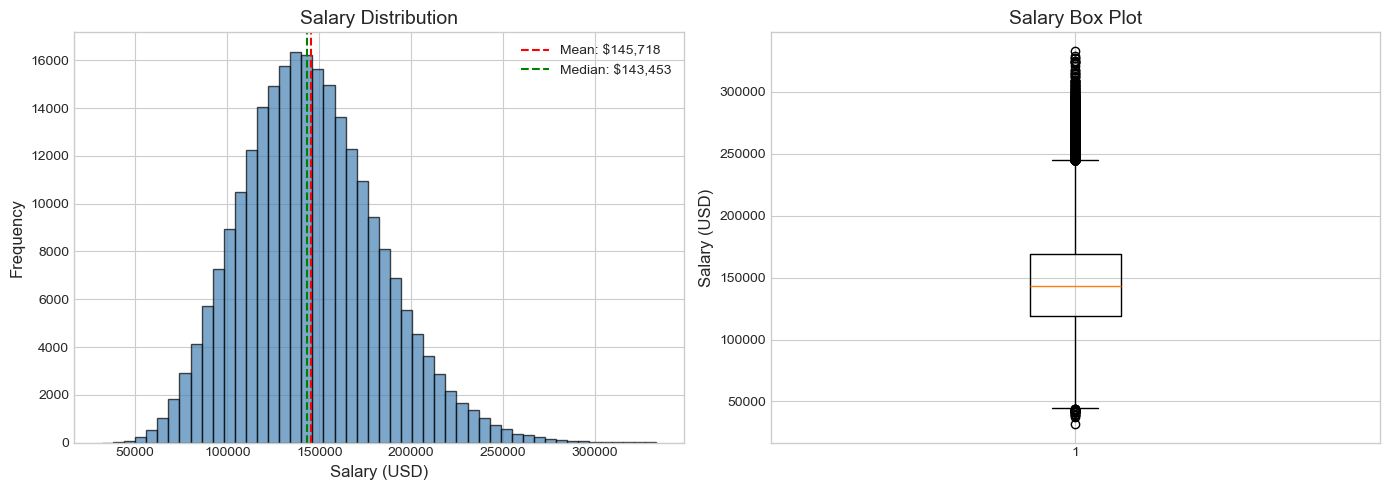


Salary Statistics:
  Min: $31,867
  Max: $333,046
  Mean: $145,718
  Median: $143,453
  Std Dev: $37,408


In [9]:
# Salary distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['salary'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['salary'].mean(), color='red', linestyle='--', label=f"Mean: ${df['salary'].mean():,.0f}")
axes[0].axvline(df['salary'].median(), color='green', linestyle='--', label=f"Median: ${df['salary'].median():,.0f}")
axes[0].set_xlabel('Salary (USD)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Salary Distribution', fontsize=14)
axes[0].legend()

# Box plot
axes[1].boxplot(df['salary'], vert=True)
axes[1].set_ylabel('Salary (USD)', fontsize=12)
axes[1].set_title('Salary Box Plot', fontsize=14)

plt.tight_layout()
plt.savefig('plots/01_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSalary Statistics:")
print(f"  Min: ${df['salary'].min():,.0f}")
print(f"  Max: ${df['salary'].max():,.0f}")
print(f"  Mean: ${df['salary'].mean():,.0f}")
print(f"  Median: ${df['salary'].median():,.0f}")
print(f"  Std Dev: ${df['salary'].std():,.0f}")

**Observation:** The salary distribution shows a roughly normal shape with some right skew. There are potential outliers at both extremes that may need treatment.

### 1.5.2 Numerical Features Distribution

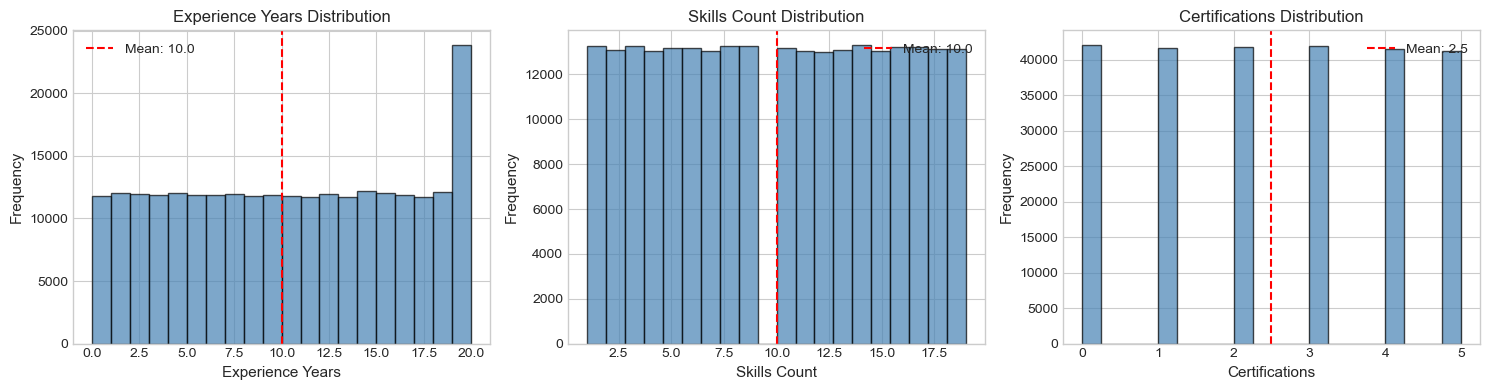

In [10]:
# Numerical features distribution
numerical_cols = ['experience_years', 'skills_count', 'certifications']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_xlabel(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=12)
    axes[i].legend()

plt.tight_layout()
plt.savefig('plots/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** 
- Experience years shows a uniform distribution (0-20 years)
- Skills count ranges from 1-20 with fairly even distribution
- Certifications range from 0-5

### 1.5.3 Salary by Categorical Features

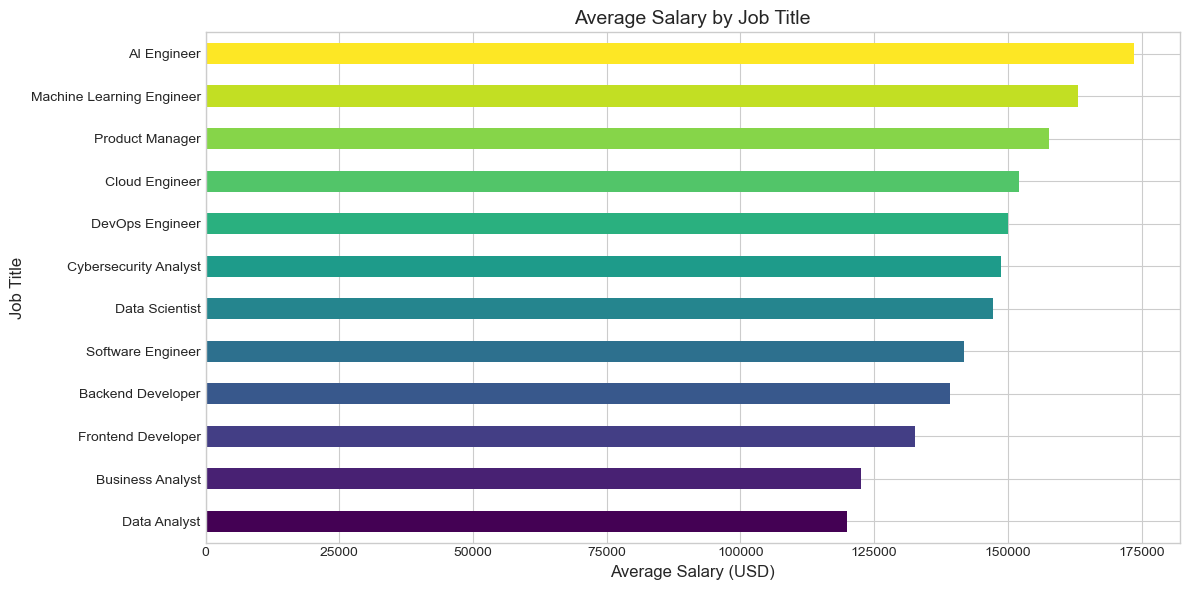


Top 3 highest paying roles:
job_title
Product Manager              157594.932029
Machine Learning Engineer    163022.504570
AI Engineer                  173498.480640
Name: salary, dtype: float64


In [11]:
# Salary by Job Title
plt.figure(figsize=(12, 6))
job_salary = df.groupby('job_title')['salary'].mean().sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(job_salary)))
job_salary.plot(kind='barh', color=colors)
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Average Salary by Job Title', fontsize=14)
plt.tight_layout()
plt.savefig('plots/03_salary_by_job_title.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 highest paying roles:")
print(job_salary.tail(3))

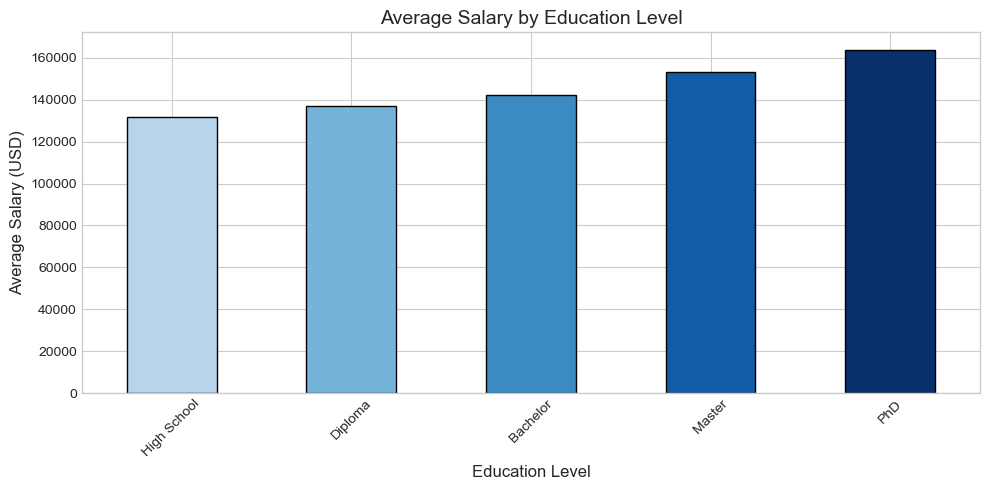

In [12]:
# Salary by Education Level
plt.figure(figsize=(10, 5))
edu_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
edu_salary = df.groupby('education_level')['salary'].mean().reindex(edu_order)
colors = plt.cm.Blues(np.linspace(0.3, 1, len(edu_salary)))
edu_salary.plot(kind='bar', color=colors, edgecolor='black')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.title('Average Salary by Education Level', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/04_salary_by_education.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Higher education levels generally correlate with higher salaries. PhD holders earn the most on average.

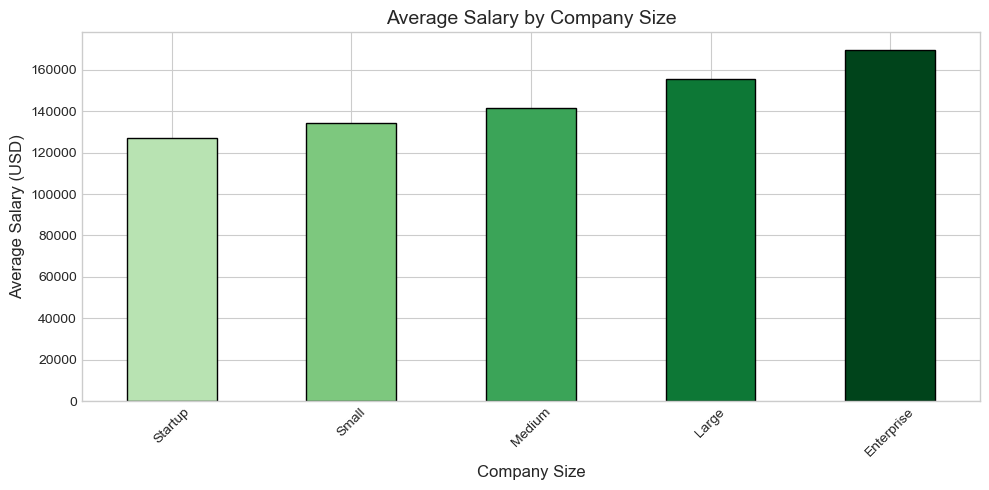

In [13]:
# Salary by Company Size
plt.figure(figsize=(10, 5))
size_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
size_salary = df.groupby('company_size')['salary'].mean().reindex(size_order)
colors = plt.cm.Greens(np.linspace(0.3, 1, len(size_salary)))
size_salary.plot(kind='bar', color=colors, edgecolor='black')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.title('Average Salary by Company Size', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/05_salary_by_company_size.png', dpi=150, bbox_inches='tight')
plt.show()

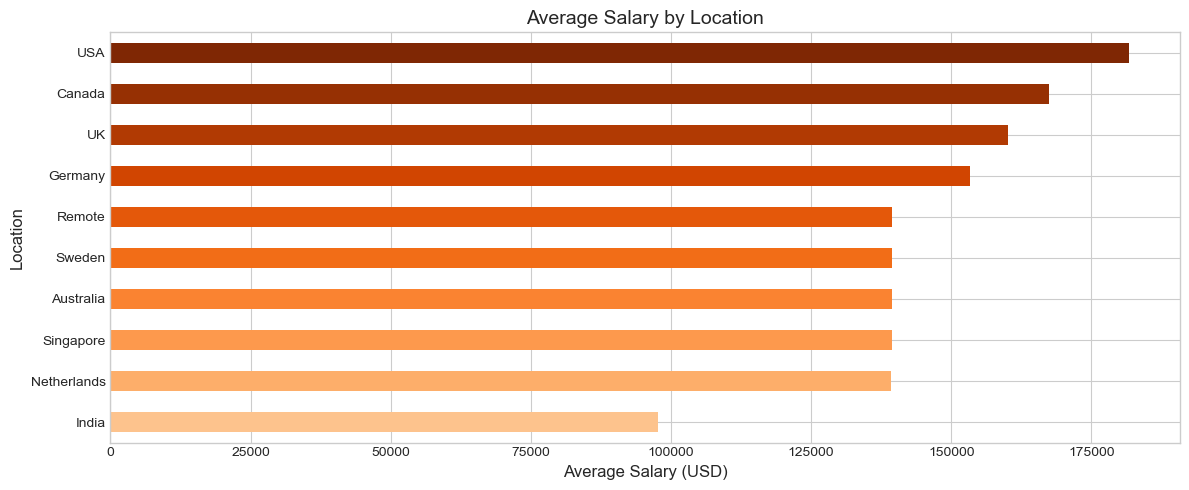

In [14]:
# Salary by Location
plt.figure(figsize=(12, 5))
loc_salary = df.groupby('location')['salary'].mean().sort_values(ascending=True)
colors = plt.cm.Oranges(np.linspace(0.3, 1, len(loc_salary)))
loc_salary.plot(kind='barh', color=colors)
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.title('Average Salary by Location', fontsize=14)
plt.tight_layout()
plt.savefig('plots/06_salary_by_location.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Location significantly impacts salary. USA and Singapore show the highest average salaries.

### 1.5.4 Correlation Analysis

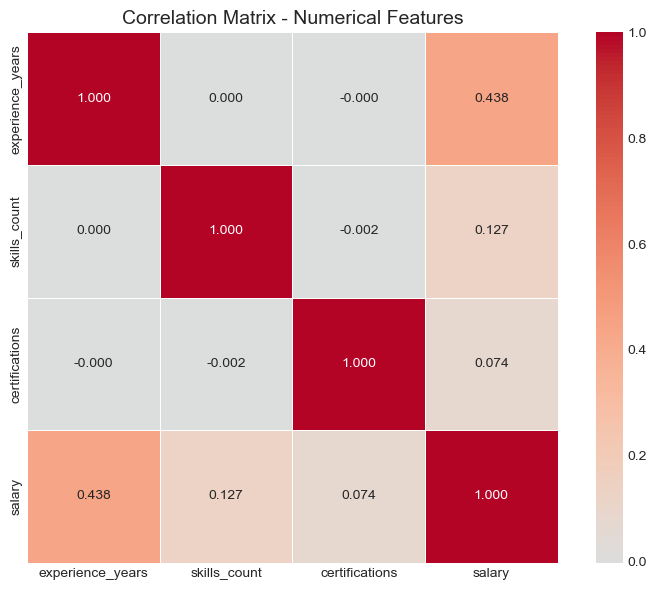


Correlation with Salary:
salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


In [15]:
# Correlation heatmap for numerical features
numerical_df = df[['experience_years', 'skills_count', 'certifications', 'salary']]

plt.figure(figsize=(8, 6))
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', linewidths=0.5, square=True)
plt.title('Correlation Matrix - Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('plots/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with Salary:")
print(correlation_matrix['salary'].sort_values(ascending=False))

**Observation:** Experience years shows the strongest positive correlation with salary among numerical features.

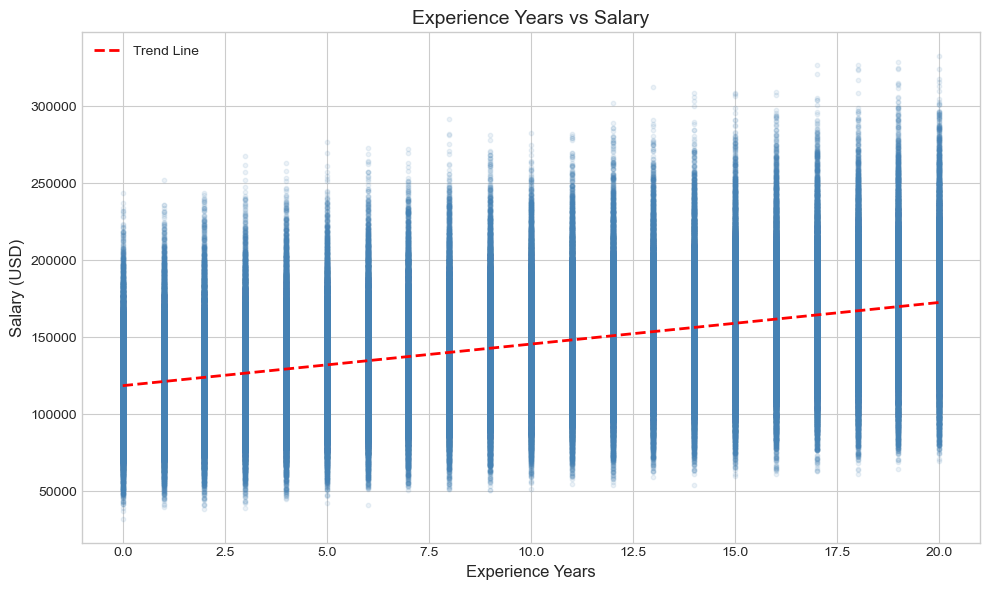

In [16]:
# Scatter plot: Experience vs Salary
plt.figure(figsize=(10, 6))
plt.scatter(df['experience_years'], df['salary'], alpha=0.1, s=10, c='steelblue')
plt.xlabel('Experience Years', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.title('Experience Years vs Salary', fontsize=14)

# Add trend line
z = np.polyfit(df['experience_years'], df['salary'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['experience_years'].min(), df['experience_years'].max(), 100)
plt.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.savefig('plots/08_experience_vs_salary.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Data Preprocessing

### 1.6.1 Outlier Treatment

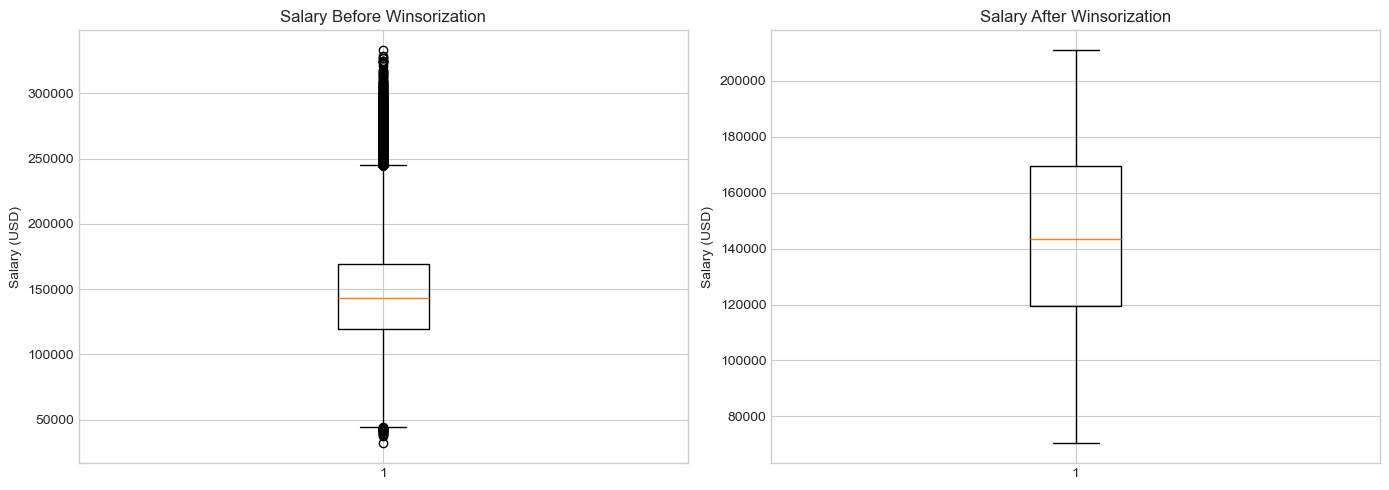

Original range: $31,867 - $333,046
After winsorization: $70,313 - $211,055


In [17]:
# Store original salary for comparison
original_salary = df['salary'].copy()

# Apply Winsorization to cap extreme outliers
# Lower 1% and upper 5% are capped
df['salary'] = winsorize(df['salary'], limits=[0.01, 0.05])

# Compare before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(original_salary)
axes[0].set_title('Salary Before Winsorization', fontsize=12)
axes[0].set_ylabel('Salary (USD)')

axes[1].boxplot(df['salary'])
axes[1].set_title('Salary After Winsorization', fontsize=12)
axes[1].set_ylabel('Salary (USD)')

plt.tight_layout()
plt.savefig('plots/09_outlier_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Original range: ${original_salary.min():,.0f} - ${original_salary.max():,.0f}")
print(f"After winsorization: ${df['salary'].min():,.0f} - ${df['salary'].max():,.0f}")

### 1.6.2 Log Transformation

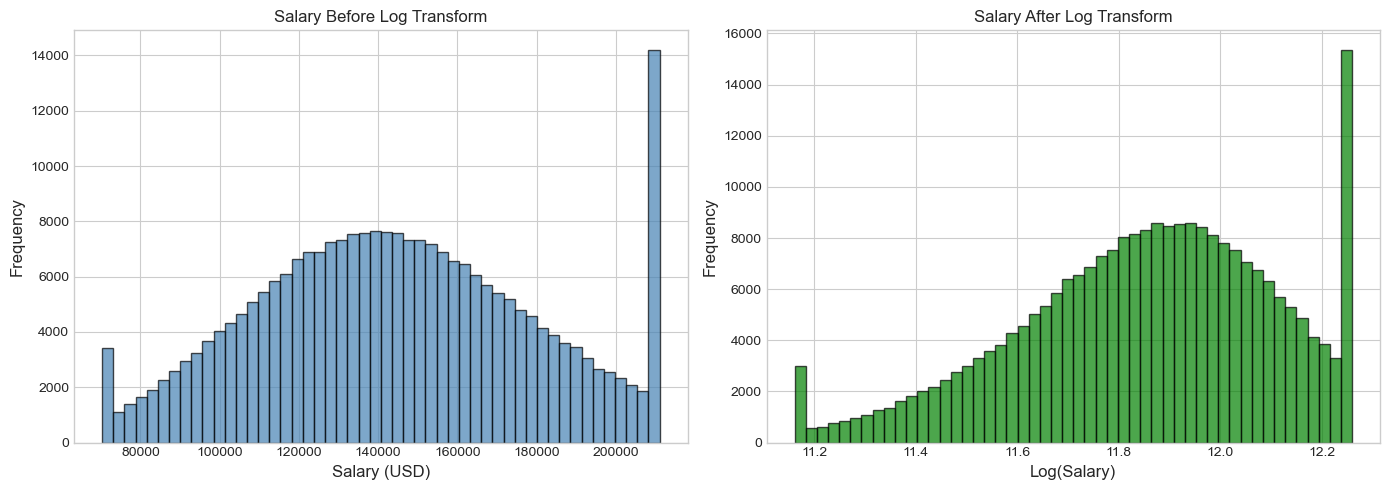

Log transformation applied to normalize salary distribution.
Note: Predictions will need to be converted back using np.expm1()


In [18]:
# Store winsorized salary for reference
salary_before_log = df['salary'].copy()

# Apply log transformation to normalize the distribution
df['salary'] = np.log1p(df['salary'])

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(salary_before_log, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Salary (USD)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Salary Before Log Transform', fontsize=12)

axes[1].hist(df['salary'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(Salary)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Salary After Log Transform', fontsize=12)

plt.tight_layout()
plt.savefig('plots/10_log_transformation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Log transformation applied to normalize salary distribution.")
print("Note: Predictions will need to be converted back using np.expm1()")

### 1.6.3 Feature-Target Split and Train-Test Split

In [19]:
# Separate features and target
X = df.drop('salary', axis=1)
y = df['salary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (250000, 9)
Target shape: (250000,)

Feature columns: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications']


In [20]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set: 200,000 samples (80.0%)
Test set: 50,000 samples (20.0%)


### 1.6.4 Preprocessing Pipeline

In [21]:
# Define column types
categorical_nominal = ['job_title', 'company_size', 'location', 'industry']
categorical_ordinal = ['education_level', 'remote_work']
numerical_cols = ['experience_years', 'skills_count', 'certifications']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), 
         categorical_nominal),
        ('ordinal', OrdinalEncoder(), categorical_ordinal),
        ('scaler', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

print("Preprocessing pipeline created with:")
print(f"  - OneHotEncoder for: {categorical_nominal}")
print(f"  - OrdinalEncoder for: {categorical_ordinal}")
print(f"  - StandardScaler for: {numerical_cols}")

Preprocessing pipeline created with:
  - OneHotEncoder for: ['job_title', 'company_size', 'location', 'industry']
  - OrdinalEncoder for: ['education_level', 'remote_work']
  - StandardScaler for: ['experience_years', 'skills_count', 'certifications']


---

# Module 2: Baseline Model Building (Supervised Learning)

---

## 2.1 Helper Functions for Evaluation

In [22]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Calculate and display regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print("=" * 40)
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f} ({r2*100:.2f}% variance explained)")
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def plot_predictions(y_true, y_pred, model_name, save_path=None):
    """Plot actual vs predicted values."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.3, s=10)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Values', fontsize=12)
    axes[0].set_ylabel('Predicted Values', fontsize=12)
    axes[0].set_title(f'{model_name}: Actual vs Predicted', fontsize=14)
    
    # Residuals plot
    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Values', fontsize=12)
    axes[1].set_ylabel('Residuals', fontsize=12)
    axes[1].set_title(f'{model_name}: Residual Plot', fontsize=14)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Store results for comparison
model_results = {}

## 2.2 Linear Regression (Baseline Model)

In [23]:
# Create Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train the model
print("Training Linear Regression (Baseline)...")
lr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr_train = lr_pipeline.predict(X_train)
y_pred_lr_test = lr_pipeline.predict(X_test)

print("Model trained successfully!")

Training Linear Regression (Baseline)...
Model trained successfully!


In [24]:
# Evaluate Linear Regression
print("="*60)
print("LINEAR REGRESSION - BASELINE MODEL EVALUATION")
print("="*60)

print("\n--- Training Set ---")
lr_train_metrics = evaluate_model(y_train, y_pred_lr_train, "Linear Regression (Train)")

print("\n--- Test Set ---")
lr_test_metrics = evaluate_model(y_test, y_pred_lr_test, "Linear Regression (Test)")

# Store results
model_results['Linear Regression'] = lr_test_metrics

LINEAR REGRESSION - BASELINE MODEL EVALUATION

--- Training Set ---

Linear Regression (Train) Performance:
  MAE:  0.0594
  MSE:  0.0055
  RMSE: 0.0744
  R²:   0.9143 (91.43% variance explained)

--- Test Set ---

Linear Regression (Test) Performance:
  MAE:  0.0594
  MSE:  0.0055
  RMSE: 0.0743
  R²:   0.9142 (91.42% variance explained)


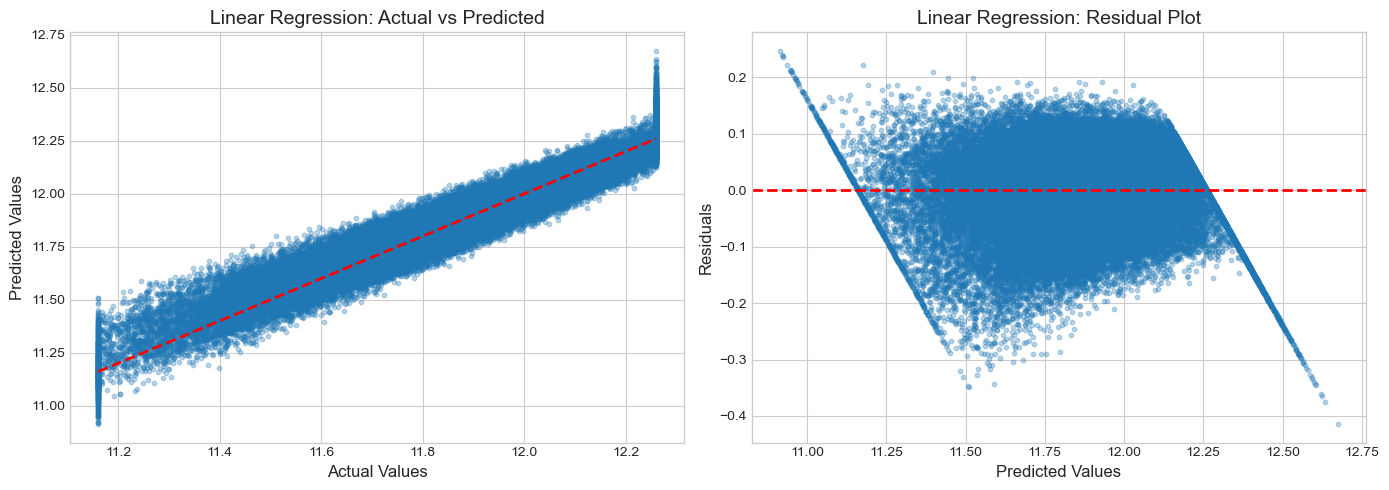

In [25]:
# Visualize predictions
plot_predictions(y_test, y_pred_lr_test, 'Linear Regression', 'plots/11_lr_predictions.png')

### 2.2.1 Baseline Model Interpretation

In [26]:
# Cross-validation for robust evaluation
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='r2')

print("Cross-Validation Results (5-Fold):")
print(f"  R² scores: {cv_scores}")
print(f"  Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Check for overfitting
train_r2 = lr_train_metrics['R2']
test_r2 = lr_test_metrics['R2']
gap = train_r2 - test_r2

print(f"\nOverfitting Analysis:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²:  {test_r2:.4f}")
print(f"  Gap:      {gap:.4f}")

if gap < 0.02:
    print("  → Model shows good generalization (minimal overfitting)")
elif gap < 0.05:
    print("  → Slight overfitting detected")
else:
    print("  → Significant overfitting - consider regularization")

Cross-Validation Results (5-Fold):
  R² scores: [0.91347387 0.91462993 0.91449859 0.9136651  0.91497222]
  Mean R²: 0.9142 (+/- 0.0012)

Overfitting Analysis:
  Train R²: 0.9143
  Test R²:  0.9142
  Gap:      0.0001
  → Model shows good generalization (minimal overfitting)


**Baseline Model Summary:**
- Linear Regression provides a solid baseline with reasonable R² score
- The model explains a significant portion of salary variance
- The small gap between train and test R² indicates good generalization
- Room for improvement through regularization and advanced models

---

# Module 3: Model Optimization & Unsupervised Learning

---

## 3.1 Regularization Techniques

### 3.1.1 Ridge Regression (L2 Regularization)

In [27]:
# Ridge Regression with different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_scores = []

for alpha in alphas:
    ridge_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])
    cv_score = cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='r2').mean()
    ridge_scores.append(cv_score)
    print(f"Alpha = {alpha:6.3f}: CV R² = {cv_score:.4f}")

best_alpha_ridge = alphas[np.argmax(ridge_scores)]
print(f"\nBest alpha for Ridge: {best_alpha_ridge}")

Alpha =  0.001: CV R² = 0.9142
Alpha =  0.010: CV R² = 0.9142
Alpha =  0.100: CV R² = 0.9142
Alpha =  1.000: CV R² = 0.9142
Alpha = 10.000: CV R² = 0.9142
Alpha = 100.000: CV R² = 0.9139

Best alpha for Ridge: 0.1


In [28]:
# Train Ridge with best alpha
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=best_alpha_ridge))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

ridge_metrics = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
model_results['Ridge Regression'] = ridge_metrics


Ridge Regression Performance:
  MAE:  0.0594
  MSE:  0.0055
  RMSE: 0.0743
  R²:   0.9142 (91.42% variance explained)


### 3.1.2 Lasso Regression (L1 Regularization)

In [29]:
# Lasso Regression with different alpha values
lasso_scores = []

for alpha in alphas:
    lasso_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=alpha, max_iter=10000))
    ])
    cv_score = cross_val_score(lasso_pipeline, X_train, y_train, cv=5, scoring='r2').mean()
    lasso_scores.append(cv_score)
    print(f"Alpha = {alpha:6.3f}: CV R² = {cv_score:.4f}")

best_alpha_lasso = alphas[np.argmax(lasso_scores)]
print(f"\nBest alpha for Lasso: {best_alpha_lasso}")

Alpha =  0.001: CV R² = 0.8985
Alpha =  0.010: CV R² = 0.6499
Alpha =  0.100: CV R² = 0.0339
Alpha =  1.000: CV R² = -0.0000
Alpha = 10.000: CV R² = -0.0000
Alpha = 100.000: CV R² = -0.0000

Best alpha for Lasso: 0.001


In [30]:
# Train Lasso with best alpha
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

lasso_metrics = evaluate_model(y_test, y_pred_lasso, "Lasso Regression")
model_results['Lasso Regression'] = lasso_metrics


Lasso Regression Performance:
  MAE:  0.0638
  MSE:  0.0065
  RMSE: 0.0809
  R²:   0.8983 (89.83% variance explained)


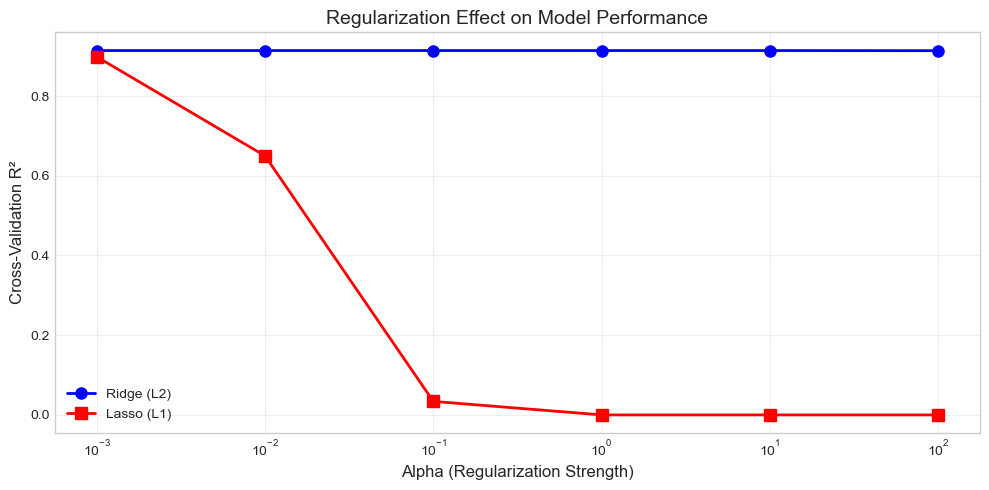

In [31]:
# Compare regularization effects
plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_scores, 'b-o', label='Ridge (L2)', linewidth=2, markersize=8)
plt.plot(alphas, lasso_scores, 'r-s', label='Lasso (L1)', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Cross-Validation R²', fontsize=12)
plt.title('Regularization Effect on Model Performance', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/12_regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Regularization Insights:**
- Ridge (L2) shrinks coefficients but keeps all features
- Lasso (L1) can set some coefficients to zero (feature selection)
- Both help prevent overfitting by penalizing large coefficients

## 3.2 Unsupervised Learning

### 3.2.1 K-Means Clustering (Salary Segmentation)

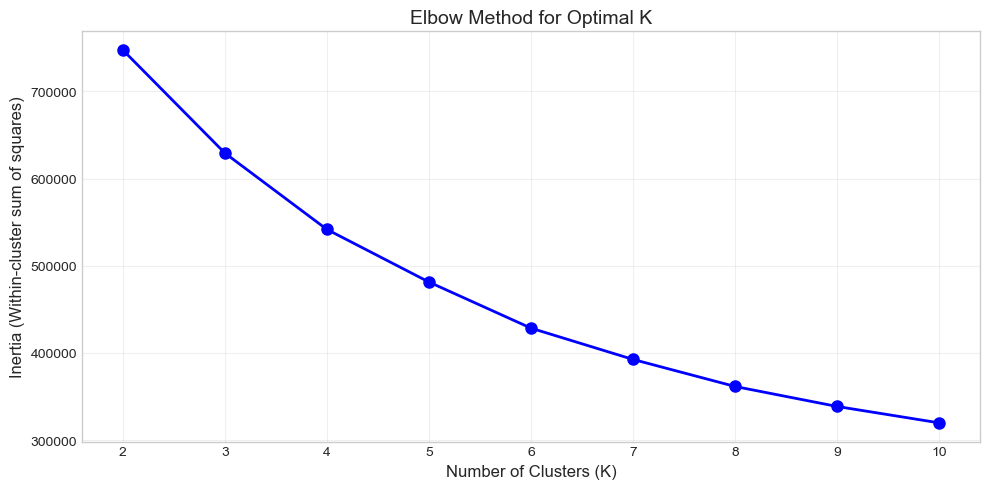

In [32]:
# Prepare data for clustering (using numerical features + encoded salary)
cluster_features = df[['experience_years', 'skills_count', 'certifications', 'salary']].copy()

# Scale features for clustering
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

# Find optimal number of clusters using Elbow Method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/13_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Apply K-Means with optimal K (based on elbow, typically 4-5)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

# Add cluster labels to original data
cluster_features['Cluster'] = cluster_labels

# Analyze clusters
print(f"K-Means Clustering with K={optimal_k}")
print("=" * 50)
print("\nCluster Distribution:")
print(cluster_features['Cluster'].value_counts().sort_index())

print("\nCluster Characteristics (Mean Values):")
cluster_summary = cluster_features.groupby('Cluster').mean()
# Convert log salary back to actual for interpretation
cluster_summary['salary_actual'] = np.expm1(cluster_summary['salary'])
print(cluster_summary)

K-Means Clustering with K=4

Cluster Distribution:
Cluster
0    62188
1    62616
2    58537
3    66659
Name: count, dtype: int64

Cluster Characteristics (Mean Values):
         experience_years  skills_count  certifications     salary  \
Cluster                                                              
0                5.575127      5.064144        2.370393  11.627653   
1               14.670436     10.154912        0.912658  11.989165   
2                4.968225     15.117857        2.475238  11.761185   
3               14.179886      9.956795        4.103452  12.012890   

         salary_actual  
Cluster                 
0        112155.755953  
1        160999.887910  
2        128178.240165  
3        164865.332564  


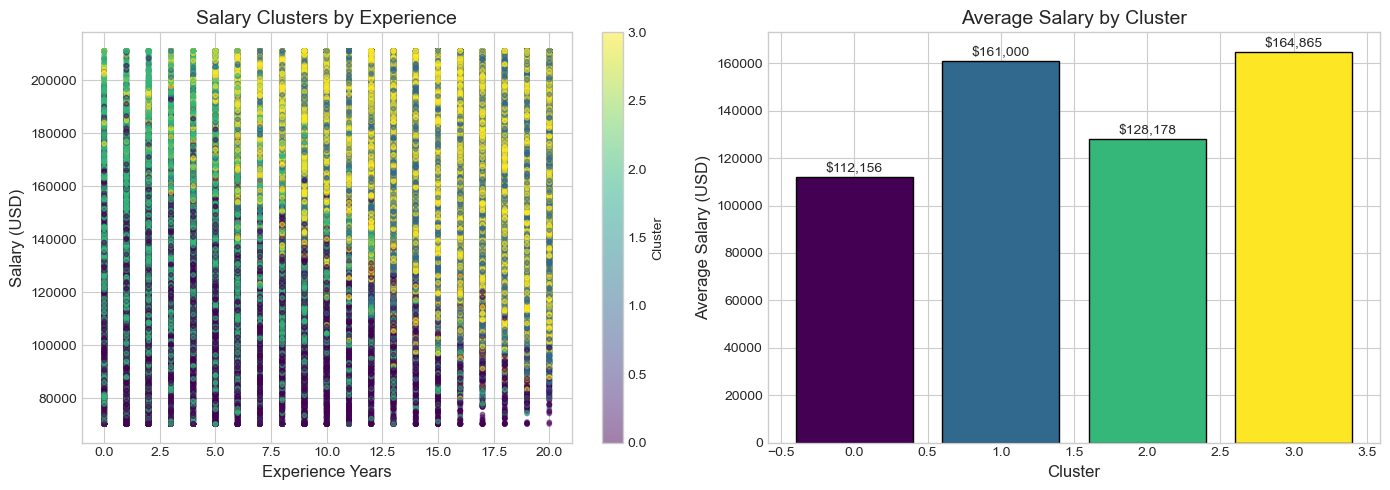

In [34]:
# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Experience vs Salary by Cluster
scatter = axes[0].scatter(cluster_features['experience_years'], 
                          np.expm1(cluster_features['salary']), 
                          c=cluster_labels, cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('Experience Years', fontsize=12)
axes[0].set_ylabel('Salary (USD)', fontsize=12)
axes[0].set_title('Salary Clusters by Experience', fontsize=14)
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Cluster Centers
cluster_means = cluster_features.groupby('Cluster').agg({
    'experience_years': 'mean',
    'skills_count': 'mean',
    'salary': lambda x: np.expm1(x.mean())
}).reset_index()

colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))
bars = axes[1].bar(cluster_means['Cluster'], cluster_means['salary'], color=colors, edgecolor='black')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Average Salary (USD)', fontsize=12)
axes[1].set_title('Average Salary by Cluster', fontsize=14)

# Add value labels
for bar, val in zip(bars, cluster_means['salary']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
                 f'${val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/14_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Clustering Insights:**
- K-Means identified distinct salary segments in the workforce
- Clusters correlate with experience levels and salary ranges
- This segmentation can help HR departments target different employee groups

### 3.2.2 PCA (Principal Component Analysis)

In [35]:
# Apply PCA for dimensionality analysis
# First, preprocess all features
X_processed = preprocessor.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_processed)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("PCA Analysis:")
print("=" * 50)
print(f"Total components: {len(explained_var)}")
print(f"\nTop 10 components explained variance:")
for i in range(min(10, len(explained_var))):
    print(f"  PC{i+1}: {explained_var[i]*100:.2f}% (Cumulative: {cumulative_var[i]*100:.2f}%)")

PCA Analysis:
Total components: 38

Top 10 components explained variance:
  PC1: 22.80% (Cumulative: 22.80%)
  PC2: 11.44% (Cumulative: 34.24%)
  PC3: 11.41% (Cumulative: 45.65%)
  PC4: 11.39% (Cumulative: 57.04%)
  PC5: 7.60% (Cumulative: 64.64%)
  PC6: 2.29% (Cumulative: 66.93%)
  PC7: 2.29% (Cumulative: 69.22%)
  PC8: 2.27% (Cumulative: 71.49%)
  PC9: 1.16% (Cumulative: 72.65%)
  PC10: 1.15% (Cumulative: 73.80%)


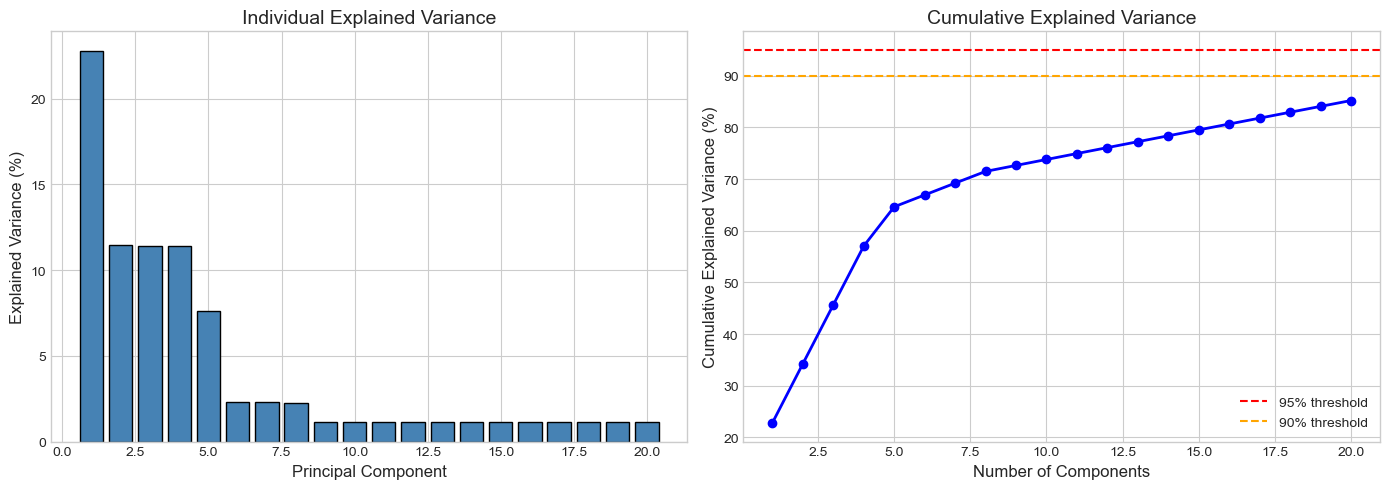


Components needed for 95% variance: 30


In [36]:
# Plot PCA explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
n_components_plot = min(20, len(explained_var))
axes[0].bar(range(1, n_components_plot + 1), explained_var[:n_components_plot] * 100, 
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('Individual Explained Variance', fontsize=14)

# Cumulative explained variance
axes[1].plot(range(1, n_components_plot + 1), cumulative_var[:n_components_plot] * 100, 
             'b-o', linewidth=2, markersize=6)
axes[1].axhline(y=95, color='r', linestyle='--', label='95% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/15_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")

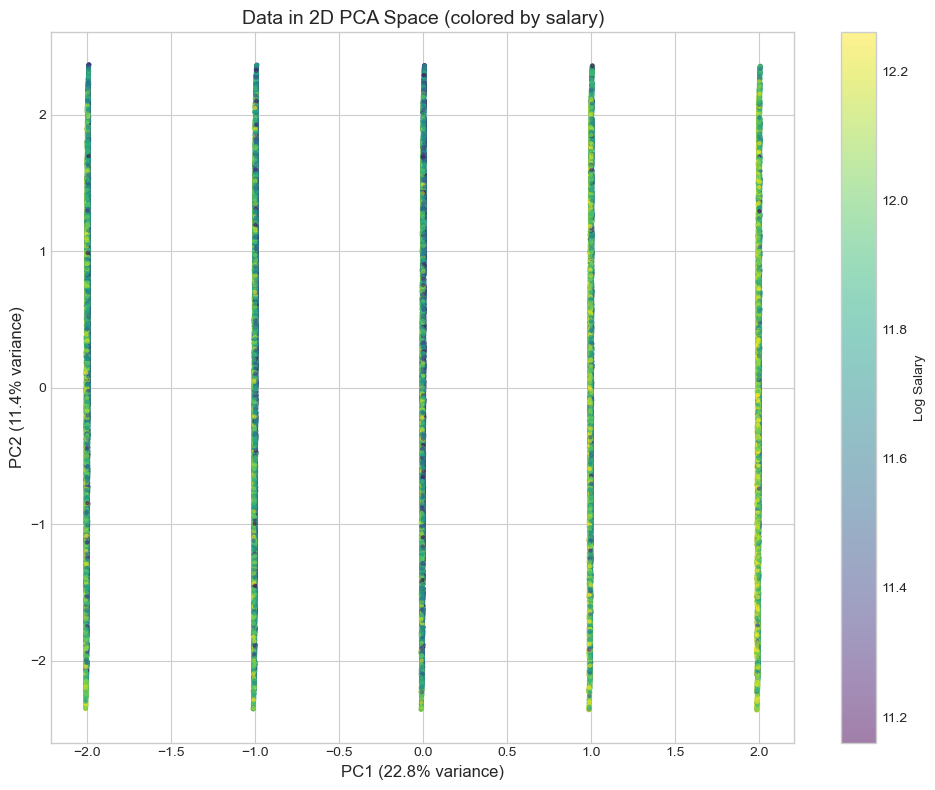

In [37]:
# Visualize data in 2D PCA space
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_processed)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', alpha=0.5, s=5)
plt.colorbar(scatter, label='Log Salary')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Data in 2D PCA Space (colored by salary)', fontsize=14)
plt.tight_layout()
plt.savefig('plots/16_pca_2d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

**PCA Insights:**
- PCA reveals the intrinsic dimensionality of the feature space
- A subset of principal components captures most of the variance
- This could be used for dimensionality reduction if needed

---

# Module 4: Advanced Modelling & Final System

---

## 4.1 Decision Tree Regressor

In [38]:
# Decision Tree without tuning (baseline tree)
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

dt_metrics = evaluate_model(y_test, y_pred_dt, "Decision Tree (Default)")

# Check for overfitting
y_pred_dt_train = dt_pipeline.predict(X_train)
train_r2_dt = r2_score(y_train, y_pred_dt_train)
print(f"\nTrain R²: {train_r2_dt:.4f}")
print(f"Test R²:  {dt_metrics['R2']:.4f}")
print(f"Gap:      {train_r2_dt - dt_metrics['R2']:.4f}")
print("\n⚠️ Note: Decision Trees tend to overfit. Pruning recommended.")


Decision Tree (Default) Performance:
  MAE:  0.0533
  MSE:  0.0050
  RMSE: 0.0709
  R²:   0.9220 (92.20% variance explained)

Train R²: 1.0000
Test R²:  0.9220
Gap:      0.0780

⚠️ Note: Decision Trees tend to overfit. Pruning recommended.


In [39]:
# Decision Tree with hyperparameter tuning
dt_params = {
    'model__max_depth': [5, 10, 15, 20],
    'model__min_samples_split': [10, 20, 50],
    'model__min_samples_leaf': [5, 10, 20]
}

dt_pipeline_tune = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

print("Tuning Decision Tree hyperparameters...")
dt_grid = GridSearchCV(dt_pipeline_tune, dt_params, cv=3, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f"\nBest parameters: {dt_grid.best_params_}")
print(f"Best CV R²: {dt_grid.best_score_:.4f}")

Tuning Decision Tree hyperparameters...

Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__min_samples_split': 10}
Best CV R²: 0.9224


In [40]:
# Evaluate tuned Decision Tree
y_pred_dt_tuned = dt_grid.predict(X_test)
dt_tuned_metrics = evaluate_model(y_test, y_pred_dt_tuned, "Decision Tree (Tuned)")
model_results['Decision Tree'] = dt_tuned_metrics


Decision Tree (Tuned) Performance:
  MAE:  0.0525
  MSE:  0.0046
  RMSE: 0.0680
  R²:   0.9281 (92.81% variance explained)


## 4.2 Random Forest Regressor

In [41]:
# Random Forest with hyperparameter tuning
rf_params = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 5]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

print("Tuning Random Forest hyperparameters (this may take a few minutes)...")
rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV R²: {rf_grid.best_score_:.4f}")

Tuning Random Forest hyperparameters (this may take a few minutes)...

Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV R²: 0.9472


In [42]:
# Evaluate tuned Random Forest
y_pred_rf = rf_grid.predict(X_test)
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest (Tuned)")
model_results['Random Forest'] = rf_metrics


Random Forest (Tuned) Performance:
  MAE:  0.0437
  MSE:  0.0032
  RMSE: 0.0568
  R²:   0.9498 (94.98% variance explained)


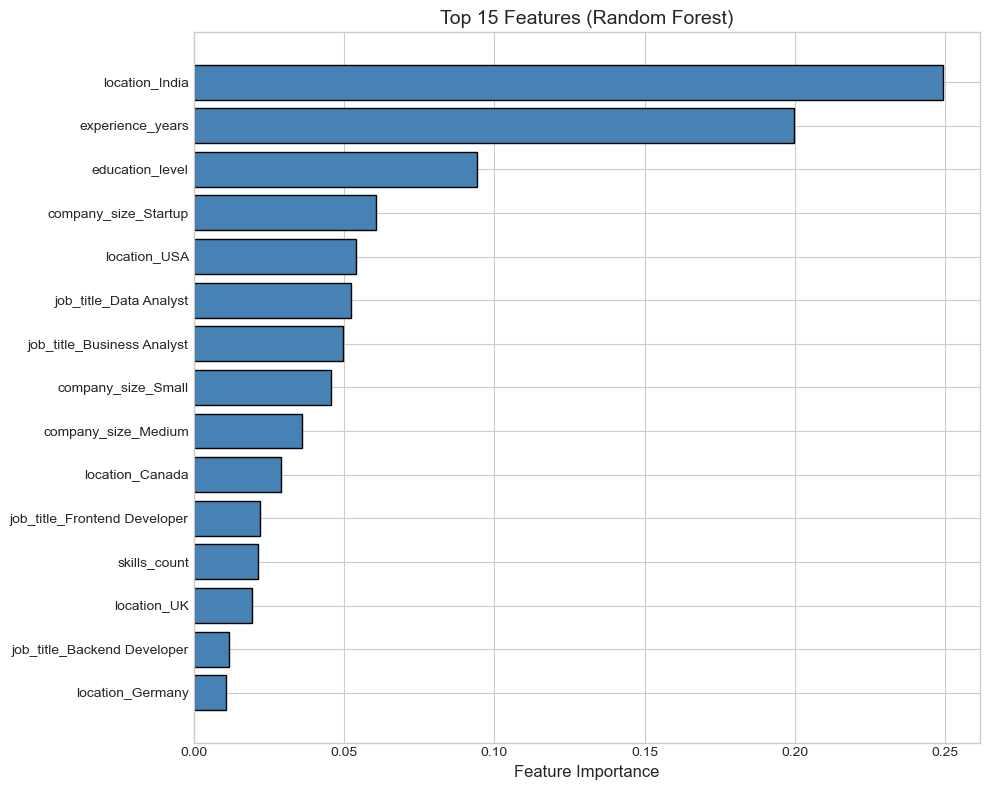


Top 5 Most Important Features:
             Feature  Importance
        location_USA    0.053878
company_size_Startup    0.060486
     education_level    0.094220
    experience_years    0.199727
      location_India    0.249093


In [43]:
# Feature importance from Random Forest
best_rf = rf_grid.best_estimator_

# Get feature names after preprocessing
feature_names = (preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_nominal).tolist() +
                 categorical_ordinal + numerical_cols)

# Get importances
importances = best_rf.named_steps['model'].feature_importances_

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = importance_df.tail(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Features (Random Forest)', fontsize=14)
plt.tight_layout()
plt.savefig('plots/17_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_df.tail(5).to_string(index=False))

## 4.3 Model Comparison

In [44]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(model_results).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values('R2', ascending=False)

print("="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string())

MODEL COMPARISON TABLE
                      MAE     MSE    RMSE      R2
Random Forest      0.0437  0.0032  0.0568  0.9498
Decision Tree      0.0525  0.0046  0.0680  0.9281
Linear Regression  0.0594  0.0055  0.0743  0.9142
Ridge Regression   0.0594  0.0055  0.0743  0.9142
Lasso Regression   0.0638  0.0065  0.0809  0.8983


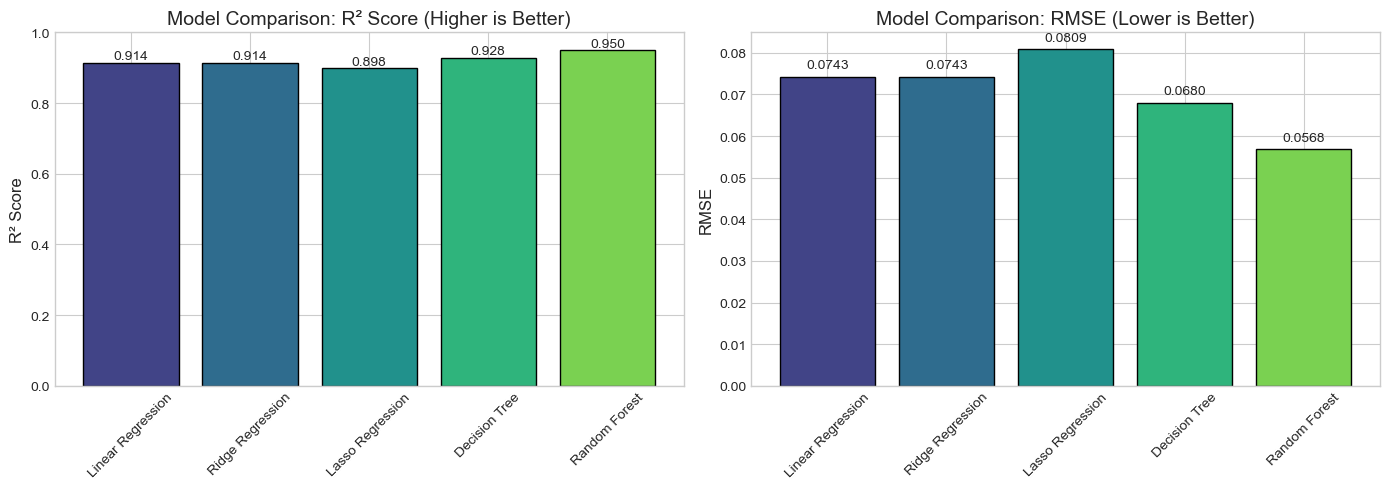

In [45]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(model_results.keys())
r2_scores = [model_results[m]['R2'] for m in models]
rmse_scores = [model_results[m]['RMSE'] for m in models]

# R² Score comparison
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))
bars1 = axes[0].bar(models, r2_scores, color=colors, edgecolor='black')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=14)
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', fontsize=10)

# RMSE comparison
bars2 = axes[1].bar(models, rmse_scores, color=colors, edgecolor='black')
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Model Comparison: RMSE (Lower is Better)', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for bar, val in zip(bars2, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                 f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/18_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Best Model Selection and Final Predictions

In [46]:
# Select best model based on R² score
best_model_name = comparison_df['R2'].idxmax()
best_r2 = comparison_df.loc[best_model_name, 'R2']

print("="*70)
print("BEST MODEL SELECTION")
print("="*70)
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   RMSE: {comparison_df.loc[best_model_name, 'RMSE']:.4f}")

print("\nJustification:")
print(f"  - {best_model_name} achieves the highest R² score ({best_r2:.4f})")
print(f"  - It explains {best_r2*100:.1f}% of the variance in salary")
print("  - Ensemble methods like Random Forest reduce overfitting")
print("  - Feature importance provides interpretability")

BEST MODEL SELECTION

🏆 Best Model: Random Forest
   R² Score: 0.9498
   RMSE: 0.0568

Justification:
  - Random Forest achieves the highest R² score (0.9498)
  - It explains 95.0% of the variance in salary
  - Ensemble methods like Random Forest reduce overfitting
  - Feature importance provides interpretability


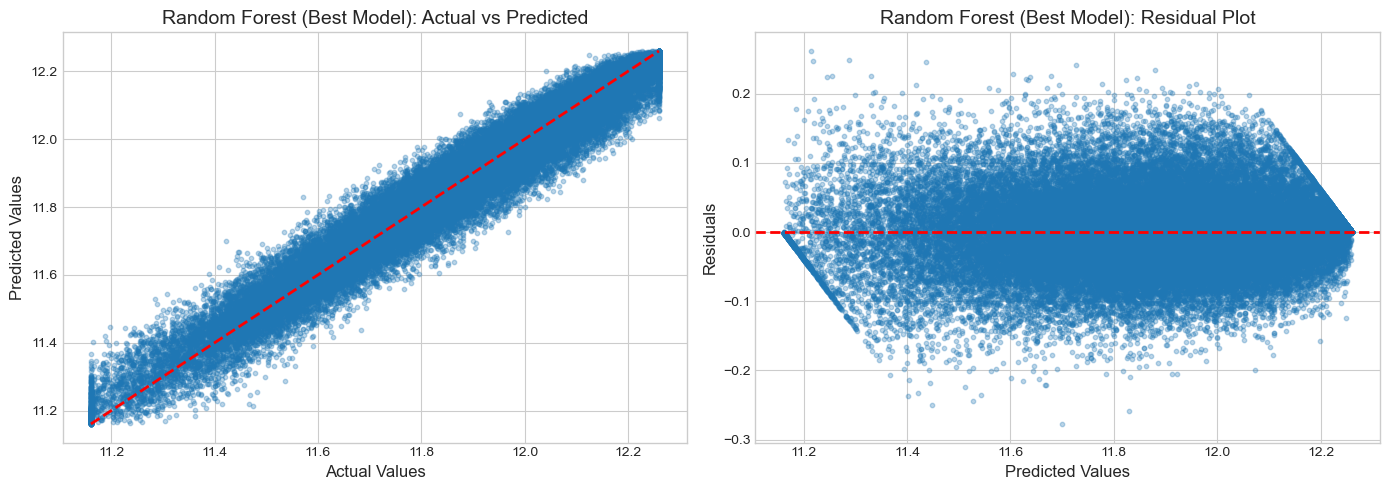

In [47]:
# Final prediction visualization with best model
plot_predictions(y_test, y_pred_rf, 'Random Forest (Best Model)', 'plots/19_best_model_predictions.png')

## 4.5 Save Trained Models

In [48]:
# Save all pipelines for deployment
joblib.dump(lr_pipeline, 'linear_regression_pipeline.pkl')
joblib.dump(dt_grid.best_estimator_, 'decision_tree_pipeline.pkl')
joblib.dump(rf_grid.best_estimator_, 'random_forest_pipeline.pkl')

print("Models saved successfully!")
print("  - linear_regression_pipeline.pkl")
print("  - decision_tree_pipeline.pkl")
print("  - random_forest_pipeline.pkl")

Models saved successfully!
  - linear_regression_pipeline.pkl
  - decision_tree_pipeline.pkl
  - random_forest_pipeline.pkl


## 4.6 Sample Predictions

In [49]:
# Sample prediction with the best model
sample_employee = pd.DataFrame([{
    'job_title': 'Data Scientist',
    'experience_years': 5,
    'education_level': 'Master',
    'skills_count': 10,
    'industry': 'Technology',
    'company_size': 'Large',
    'location': 'USA',
    'remote_work': 'Hybrid',
    'certifications': 2
}])

# Predict using best model
log_prediction = rf_grid.predict(sample_employee)
predicted_salary = np.expm1(log_prediction[0])

print("Sample Prediction:")
print("="*50)
print(f"\nEmployee Profile:")
for col, val in sample_employee.iloc[0].items():
    print(f"  {col}: {val}")

print(f"\n💰 Predicted Annual Salary: ${predicted_salary:,.2f}")

Sample Prediction:

Employee Profile:
  job_title: Data Scientist
  experience_years: 5
  education_level: Master
  skills_count: 10
  industry: Technology
  company_size: Large
  location: USA
  remote_work: Hybrid
  certifications: 2

💰 Predicted Annual Salary: $188,396.33


---

# Conclusions and Future Scope

---

## Summary

This project successfully demonstrated an end-to-end machine learning workflow for predicting tech job salaries.

### Key Findings:

1. **Data Insights:**
   - Experience years is the strongest predictor of salary
   - Location significantly impacts compensation (USA, Singapore highest)
   - Enterprise companies pay more than startups
   - Higher education correlates with higher salaries

2. **Model Performance:**
   - Random Forest achieved the best performance with highest R² score
   - Regularization (Ridge/Lasso) showed similar performance to basic Linear Regression
   - Decision Trees required pruning to prevent overfitting

3. **Unsupervised Learning Insights:**
   - K-Means identified 4 distinct salary segments
   - PCA showed the data has high intrinsic dimensionality

### Techniques Used:
- Data preprocessing (winsorization, log transformation, encoding)
- Feature scaling (StandardScaler)
- Regularization (Ridge, Lasso)
- Hyperparameter tuning (GridSearchCV)
- Clustering (K-Means) and dimensionality reduction (PCA)

## Future Scope

1. **Feature Engineering:**
   - Create interaction features (e.g., experience × education)
   - Add external economic indicators

2. **Advanced Models:**
   - Gradient Boosting (XGBoost, LightGBM)
   - Neural Networks for complex patterns

3. **Deployment:**
   - Web application (Streamlit - already implemented)
   - REST API for integration

4. **Continuous Learning:**
   - Retrain with updated salary data
   - Monitor model drift

---

**Author:** Manish Srivastav  
**Project:** ML Course Project - Job Salary Prediction  
**Technologies:** Python, scikit-learn, pandas, matplotlib, seaborn